# Naive Bayes Classification - Social Network Ads

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


 Load and Explore the Dataset

In [29]:
# loading the dataset
df = pd.read_csv('Social_Network_Ads.csv')
df.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [30]:
# checking shape
print("Shape of dataset:", df.shape)

Shape of dataset: (400, 5)


In [31]:
# basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [32]:
# statistical summary
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [33]:
# checking null values

print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [34]:
# checking class distribution
print("Value counts of target variable (Purchased):")
print(df['Purchased'].value_counts())

Value counts of target variable (Purchased):
Purchased
0    257
1    143
Name: count, dtype: int64


 Exploratory Data Analysis (EDA)

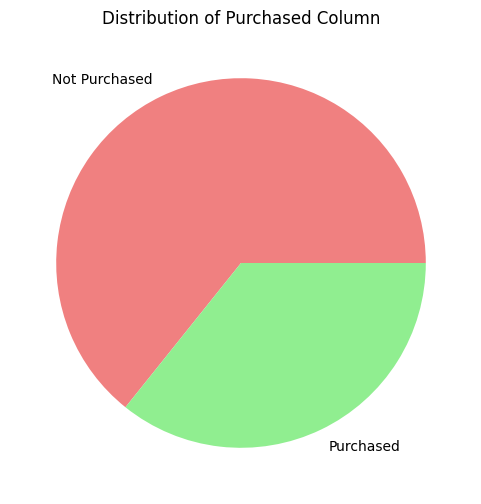

In [35]:
# pie chart for target variable
plt.figure(figsize=(6,6))
df['Purchased'].value_counts().plot(kind='pie',  labels=['Not Purchased', 'Purchased'], colors=['lightcoral', 'lightgreen'])
plt.title('Distribution of Purchased Column')
plt.ylabel('')
plt.show()

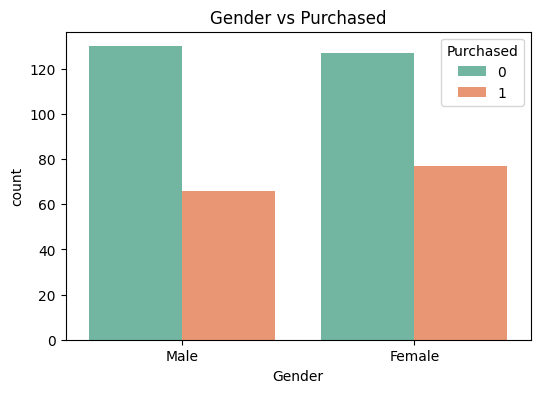

In [36]:
# countplot for gender
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Purchased', data=df, palette='Set2')
plt.title('Gender vs Purchased')
plt.show()

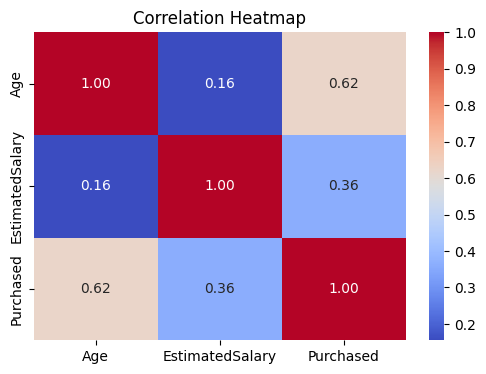

In [37]:
# correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'EstimatedSalary', 'Purchased']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Data Preprocessing

In [38]:
# dropping User ID column as it is not useful
df = df.drop('User ID', axis=1)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [39]:
# encoding gender column (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print("After encoding:")
df.head()

After encoding:


,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


In [40]:
# separating features and target variable
X = df.drop('Purchased', axis=1)   # features
y = df['Purchased']                 # target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (400, 3)
Target shape: (400,)


In [41]:
# train test split  (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (320, 3)
Testing size: (80, 3)


In [42]:
# feature scaling - important for many ML algorithms
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)   # note: only transform on test, not fit_transform


Applying Naive Bayes


In [43]:
# training the model
classifier = GaussianNB()
classifier.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [44]:
# predicting on test set
y_pred = classifier.predict(X_test)

print("Predictions:", y_pred[:10])
print("Actual values:", y_test.values[:10])

Predictions: [1 1 0 1 0 0 1 0 0 0]
Actual values: [0 1 0 1 0 0 1 0 0 0]


 Model Evaluation

In [45]:
# accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy of Naive Bayes Model: {acc * 100:.2f}%")

Accuracy of Naive Bayes Model: 93.75%


In [46]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[50  2]
 [ 3 25]]


In [47]:
# classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.94      0.96      0.95        52
    Purchased       0.93      0.89      0.91        28

     accuracy                           0.94        80
    macro avg       0.93      0.93      0.93        80
 weighted avg       0.94      0.94      0.94        80

